# Python: OOP +JSON

## Objected Oriented Programming in Python

### Brief theory

***Object oriented programming*** is a data-centered programming paradigm that is based on the idea of grouping data and functions that act on particular data in so-called classes.

A ***class*** can be seen as a complex data-type, a template if you will.

***Variables*** that are of that data type are said to be **objects** or **instances** of that class.

In [3]:
class Person:
    def __init__(self, name, age):
        self.name = name
        self.age = age

Here we created a class Person with a function *__init__*.

Functions that start with underscores are always special functions to Python which are connected with other built-in aspects of the language.

Functions within a class are called **methods**.

The initialisation method assigns the two parameters that are passed to variables that belong to the object, within a class definition the object is always represented by self.

The first argument of a method is always *self*, and it will always point to the instance of the class. This first argument however is never explicitly specified when you call the method. It is implicitly passed by Python itself. That is why you see a discrepancy between the number of arguments in the instantiation and in the class definition.

Any *variable or methods in a class can be accessed using the period* (.) syntax:

*object.variable*

or

*object.method*


The *initialisation function* will be called when an object of that initialised. Let's do so:

In [4]:
instructor = Person("Anna", 20)
print("My name is " + instructor.name)
print("My age is " + str(instructor.age))

My name is Anna
My age is 20


Unbeknowst to you, we have already made use of countless objects and methods throughout this course.
Things like strings, lists, sets, dictionaries are all objects! The object oriented paradigm is ubiquitous in Python!

 Let's extend our example (to print the name and age):

In [5]:
class Person:
    def __init__(self, name, age):
        self.name = name
        self.age = age

    def introduceyourself(self):
        print("My name is " + self.name)
        print("My age is " + str(self.age))

instructor = Person("Hanna",25)
instructor.introduceyourself()

My name is Hanna
My age is 25


When the method is called, Python replaces the *self* argument with the instance object

Methods like .__init__() and .__str__() are called **dunder methods** because they begin and end with double underscores.

There are many dunder methods that you can use to customize classes in Python
[When Should You Use .__repr__() vs .__str__() in Python?](https://realpython.com/python-repr-vs-str/)

Attributes created in .__init__() are called *instance attributes*.
An instance attribute’s value is specific to a particular instance of the class

On the other hand, **class attributes** are attributes that have the same value for all class instances.
You can define a class attribute by assigning a value to a variable name outside of .__init__().

In [6]:
class Person:
    whoIs="homo sapiens"
    def __init__(self, name, age):
        self.name = name
        self.age = age

    def introduceyourself(self):
        print("My name is " + self.name)
        print("My age is " + str(self.age))

instructor = Person("Hanna",25)
instructor.introduceyourself()

My name is Hanna
My age is 25


When you create an instance of the class, then Python automatically creates and assigns class attributes to their initial values.

In [7]:
instructor1 = Person("Hanna",25)
print(instructor1.whoIs)
instructor1.whoIs="woman"

instructor2 = Person("Anna",20)
instructor2.whoIs

homo sapiens


'homo sapiens'

To determine which class a given object belongs to, you can use the *built-in type()*:

In [8]:
type(instructor1)

__main__.Person

[Getters and Setters: Manage Attributes in Python](https://realpython.com/python-getter-setter/)

In [12]:
class Person:
    whoIs="homo sapiens"
    def __init__(self, name, age):
        self._name = name

    @property
    def name(self):
        return self._name

    @name.setter
    def name(self, value):
        self._name = value

class Teacher(Person): #this class inherits the class Person
    @property
    def name(self):
      return super().name.title()

instructor1 = Person("Hanna",25)
print(instructor1.name)
instructor1.name="Anna"
print(instructor1.name)

instructor2 = Teacher("franco",20)
print(instructor2.name)
#instructor2.name="Anna" # AttributeError: property 'name' of 'Teacher' object has no setter




Hanna
Anna
Franco


A **class method** is a method that is bound to a class rather than its object. It doesn't require creation of a class instance.

Class method works with the class since its parameter is always the class itself.

The class method can be called both by the class and its object.

You can use the @classmethod decorator for classmethod definition
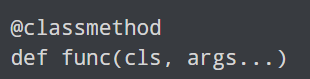

The class method is always attached to a class with the first argument as the class itself *cls*

*When do you use the class method?*
1. *Factory methods*

are those methods that return a class object (like constructor) for different use cases.

It is similar to function overloading in C++ . Since, Python doesn't have anything as such, class methods and static methods are used.

In [13]:
from datetime import date

class Person:
    whoIs="homo sapiens"
    def __init__(self, name, age):
        self.name = name
        self.age = age

    def introduceyourself(self):
        print("My name is " + self.name)
        print("My age is " + str(self.age))

    @classmethod
    def fromBirthYear(cls, name, birthYear):
        return cls(name, date.today().year - birthYear)

instructor = Person.fromBirthYear('Hanna',  2000)
instructor.introduceyourself()

My name is Hanna
My age is 25


2. Correct instance creation in *inheritance* - see later...

**Inheritance**

You can build more specialised classes on top of more generic classes.
*Person* for instance is a rather generic concept. We can use this generic class to build a more specialised class *Teacher*, a person that teaches a course.

If you use inheritance, everything that the parent class could do, the inherited class can do as well!

The syntax for inheritance is as follows, do not confuse it with parameters in a function/method definition.

We also add an extra method *stateprofession()* otherwise *Teacher* would be no different than *Person*:

In [14]:
class Person:
    def __init__(self, name, age):
        self.name = name
        self.age = age

    def introduceyourself(self):
        print("My name is " + self.name)
        print("My age is " + str(self.age))


class Teacher(Person): #this class inherits the class Person
    def stateprofession(self):
        print("I am a teacher!")

In [15]:
instructor = Teacher("Hanna",20)
instructor.introduceyourself()
instructor.stateprofession()

My name is Hanna
My age is 20
I am a teacher!


In OOP, Inheritance signifies an IS-A relation.

**Overloading VS Overriding**

**Overloading** refers to the ability to define a function with the same name multiple times and seeing different results depending on the number or types of the parameters.

**Overriding** refers to having a method with the same name in the child class as in the parent class. The definition of the method differs in parent and child classes but the name remains the same.

**!!!** Overriding means that the first definition will not be available anymore.



Instead of completely overloading a method, you can also **call the method of the parent class** (to avoid repetition of code.

We need to keep track of the courses that are taught by the teacher.

In [16]:
class Teacher(Person): #this class inherits the class Person
    def __init__(self, name, age):
        self.courses = [] #initialise a new variable
        super().__init__(name,age) #call the init of Person

    def stateOccupation(self):
        print("I am a teacher!")

    def introduceyourself(self):
        super().introduceyourself() #call the introduceyourself() of the Person
        self.stateOccupation()
        print("I teach " + str(self.nCourses()) + " course(s)")
        for course in self.courses:
            print("I teach " + course)



    def addcourse(self, course):
        self.courses.append(course)

    def nCourses(self):
        return len(self.courses)



In [17]:
instructor = Teacher("Hanna",20)
instructor.addcourse("Software Engineering")
instructor.addcourse("AI")
instructor.introduceyourself()

My name is Hanna
My age is 20
I am a teacher!
I teach 2 course(s)
I teach Software Engineering
I teach AI


Whenever you derive a class from implementing a factory method as a **class method**, it ensures correct instance creation of the derived class.

In [18]:
from datetime import date

class Person:
    whoIs="homo sapiens"
    def __init__(self, name, age):
        self.name = name
        self.age = age

    def introduceyourself(self):
        print("My name is " + self.name)
        print("My age is " + str(self.age))

    @classmethod
    def fromBirthYear(cls, name, birthYear):
        return cls(name, date.today().year - birthYear)


class Instructor(Person): #this class inherits the class Person
    whoIs="smart homo sapiens"
    def __init__(self, name, age):
        self.courses = [] #initialise a new variable
        super().__init__(name,age) #call the init of Person


instructor1 = Instructor("Hanna",20)
instructor1.whoIs

'smart homo sapiens'

**Static methods**, as the name suggests, are not bound to either the class or its instances. They are defined using the *@staticmethod* decorator and do not take a reference to the instance or the class as their first parameter.

Static methods are essentially regular functions within the class namespace and are useful for tasks that do not depend on instance-specific or class-specific data.

A static method can be called on the class itself, rather than on an instance of the class.

One of the main benefits of using static methods in Python is that they can be called without creating an instance of the class. This makes them useful for utility functions and other methods that don’t need access to instance-specific data.

Another advantage of using static methods is that they can improve the organization and readability of your code. By grouping related functions and utility methods together in a single class, you can make it easier to understand the purpose and functionality of each part of your code.

In [22]:
from datetime import date

class Instructor(Person): #this class inherits the class Person
    whoIs="smart homo sapiens"
    def __init__(self, name, age):
        self.courses = [] #initialise a new variable
        super().__init__(name,age) #call the init of Person

    @staticmethod
    def is_weekday(day):
        if day.weekday() == 5 or day.weekday() == 6:
            return False
        return True


instructor1 = Instructor("Hanna",20)
day = date(2024, 12, 25)
instructor1.is_weekday(day)

True

### Exercises

**Exercise 1:**
Our app has users that are either instructors or students.

Instructors and students will share certain attributes and have certain behaviors that are unique to them.
You'll be defining a Person class that both students and instructors inherit from and you'll be writing methods within both the Instructor and Student class that are unique to that class.

1. Define the Person class such that a user is instantiated with a first_name and last_name. These should be saved as attributes.

2. We've given you a barebones Instructor class in instructor.py

We've given you a list of knowledge strings below; modify the Instructor class so that it initializes with this list. Use @property syntax to create your property knowledge.

3. Create the teach() method in the Instructor class so that it returns a random element from knowledge list. We need to import Python's random library. You will want to use the random.randint() method to choose a random index in knowledge list. This method takes 2 arguments, a minimum number and a maximum number, and returns a random element in the range.

4. We've given you a barebones Student class. Individual students should initialize with an attribute, knowledge, that points to an empty list.

5. Create the learn() method in the Student class so that in takes in a string and adds that string to the student's knowledge list


In [20]:
knowledge = [
    "str is a data type in Python",
    "programming is hard, but it's worth it",
    "JavaScript async web request",
    "Python function call definition",
    "object-oriented teacher instance",
    "programming computers hacking learning terminal",
    "pipenv install pipenv shell",
    "pytest -x flag to fail fast",
]

**Operator overloading**
If you write your own classes, you can define what needs to happen if an operator such as for example `+`,`/` or `<` is used on your class.

You can also define what happens when the keyword `in` or built-in functions such as `len()` are you used with your class. This allows for a very elegant way of programming.

Each of these operators and built-in functions have an associated method which you can overload. All of these methods start, like `__init__`, with a double underscore.


For example. Let's allow comparison of persons using the '<' and '>' operators. The methods for the opertors are respectively __lt__ and __gt__, both take one argument, the other object to compare to. A person qualifies as older than another if the age value is bigger:

In [23]:
from datetime import date

class Person:
    whoIs="homo sapiens"
    def __init__(self, name, age):
        self.name = name
        self.age = age

    def __lt__(self, other):
        return self.age < other.age

    def __gt__(self, other):
        return self.age > other.age

instructor1 = Instructor("Hanna",30)
instructor2 = Instructor("Franco",20)
print(instructor1 > instructor2)

True


You may not yet see much use in this, but consider for example the built-in function sorted().

Having such methods defined now means we can sort our persons.

And because we defined the methods __lt__ and __gt__ based on time. It will automatically sort them on time, from old to young.

In [24]:
CSdepartment = [instructor2,instructor1]

for instructor in sorted(CSdepartment):
    print(instructor.name)

Franco
Hanna


Remember the in keyword? Used checking items in lists and keys in dictionaries?

In [25]:
instructors = ['Hanna','Franco']
print('hanna' in instructors)

False


Overloading this operator is done using the __contains__ method. It takes as extra argument the item that is being searched for ('hanna' in the above example).

**Exercise 2:**

For Instructor, let's implement support for the *in* operator and have it check whether a certain element is in the knowledge list.

In [ ]:
class Instructor (Person):
    #your code is here...

    def __contains__(self, skill):
        #Implement the method

**Iteration over an object**
Remember how we can iterate over lists and dictionaries using a for loop?


In [ ]:
instructors = ['Hanna','Franco']
for instructor in instructors:
    print(instructor)

Hanna
Franco


We can do the same for our own object. We can make them support iteration.

This is done by overloading the __iter__ method. It takes no extra arguments and should be a generator. Which if you recall means that you should use yield instead of return.

Consider the following class Person, if we iterate over an instance of that class, we want to iterate over all hobbies. To make it more fun, let's iterate in chronologically sorted order:

In [27]:
class Person:
    whoIs="homo sapiens"
    def __init__(self, name, age):
        self.name = name
        self.age = age
        self.hobbies=[]

    def append(self, hobby):
      self.hobbies.append(hobby)

    def __iter__(self):
        for hobby in sorted(self.hobbies):
            yield hobby

**Exercise 3:**

The method __len__ is invoked when the built-in function len() is used. We want it to return the number of skills a student has.

https://github.com/BenedictusAryo/OOP_Python/tree/master

https://docs.python.org/3.8/

https://docs.python.org/3/tutorial/classes.html#inheritance

https://realpython.com/operator-function-overloading/

https://realpython.com/inheritance-composition-python/


## Working with The JSON Data Format

A lot of data in the real world is naturally hierarchical. The JavaScript Object Notation, or **JSON**, data format is a popular way to represent hierarchical data. Despite its name, its application extends far beyond JavaScript, the language for which it was originally designed.

JSON has a straightforward syntax. It consists of *key-value* pairs. 
The key represents strings while the value can consist of any JSON data type ranging from booleans to integers.

### Python Libraries to work with JSON data

There are a few popular Python packages that you can use to work with JSON files:

* **json**. This is a built-in Python package that provides methods for encoding and decoding JSON data.
* **simplejson**. This package provides a fast JSON encoder and decoder with support for Python-specific types.
* **ujson**. This package is an ultra-fast JSON encoder and decoder for Python.
* **jsonschema**. This package provides a way to validate JSON data against a specified schema.

In [1]:
import json

### JSON Serialization and Deserialization

JSON serialization and deserialization are the processes of converting JSON data to and from other formats, such as Python objects or strings, to transmit or store the data.

**Serialization** is the process of converting an object or data structure into a JSON string. This process is necessary in order to transmit or store the data in a format that can be read by other systems or programs. JSON serialization is a common technique used in web development, where data is often transmitted between different systems or applications.

**Deserialization**, on the other hand, is the process of converting a JSON string back into an object or data structure. This process is necessary to use the data in a program or system. JSON deserialization is often used in web development to parse data received from an API or other source.

**JSON serialization and deserialization are important techniques for working with JSON data** in various contexts, from web development to data analysis and beyond. Many programming languages provide built-in libraries or packages to make serialization and deserialization easy and efficient.

!!! Python and JSON have different data types

In [4]:
# Python object to JSON string
python_obj = {'name': 'Hanna', 'age': 10}

json_string = json.dumps(python_obj) #This function is used to serialize a Python object into a JSON string, takes a single argument, the Python object

#and returns a JSON string
print(json_string)  

# Expected output: {"name": "Hanna", "age": 10}

{"name": "Hanna", "age": 10}


In [6]:
# JSON string to Python object
json_string = '{"name": "Hanna", "age": 10}'

python_obj = json.loads(json_string) #is used to parse a JSON string into a Python object

#returns a Python object
print(python_obj)  

# Expected output: {'name': 'Hanna', 'age': 10}

{'name': 'Hanna', 'age': 10}


In [ ]:
# serialize Python object and write to JSON file
python_obj = {'name': 'Hanna', 'age': 10}
with open('data.json', 'w') as file:
    json.dump(python_obj, file) #takes 2 arguments, the Python object and the file object.

# No expected output

In [8]:
# read JSON file and parse contents
with open('data.json', 'r') as file:
    python_obj = json.load(file)
print(python_obj)  

# Expected output: {'name': 'Hanna', 'age': 10}

{'name': 'Hanna', 'age': 10}


### JSON File: Read & Write


In [ ]:
json_files = [os.path.join(root, name) 
              for root, dirs, files in os.walk(path) 
              for name in files 
              if name.endswith((".json"))] #If we needed to read several files extensions: if name.endswith((".ext1", ".ext2"))

print('Number of JSON files ready to be loaded: ' + str(len(json_files)))

In [9]:
try:
    # Open and read the JSON file
    with open('data.json', 'r') as file:
        data = json.load(file)
        print(json.dumps(data, indent=4))  # Beautify the printed JSON

except FileNotFoundError:
        print("The file was not found.")

except json.JSONDecodeError:
        print("The file contains invalid JSON.")

{
    "name": "Hanna",
    "age": 10
}


In [12]:
file_name = "data/data1.json"

But first let's will  all the JSON files inside the main Directory and any sub-Folder:

In [13]:
import io
import os

In [14]:
path="data"

In [15]:
json_files = [os.path.join(root, name) 
              for root, dirs, files in os.walk(path) 
              for name in files 
              if name.endswith((".json"))] #If we needed to read several files extensions: if name.endswith((".ext1", ".ext2"))

print('Number of JSON files ready to be loaded: ' + str(len(json_files)))

Number of JSON files ready to be loaded: 1


In [16]:
json_files

['data\\data1.json']

In [17]:
print('Path to the first file: '+json_files[0])

Path to the first file: data\data1.json


In [18]:
#Open the file using the name of the json file with open() function
#Read the json file using load() and put the json data into a variable.
with open(json_files[0]) as f:
   json_data = json.load(f)

In [19]:
json_data

{'name': 'Franco', 'age': 5}

A "variable" with multiple values is called a repeated field. 

A repeated field might itself contain a **repeated field** , creating a hierarchy of variables. Repeated fields are represented as lists or arrays in JSON.

In [20]:
# Python object to JSON string
python_obj2 = {
  "departments": [
    {
      "name": "Computer Science",
      "teams": [
        { "teamName": "Frontend", "members": ["Hanna", "Ubaid"] },
        { "teamName": "Backend", "members": ["Franco", "Brain"] }
      ]
    }
  ]
}

In [21]:
python_obj2.keys() #the top-level variable 

dict_keys(['departments'])

In [22]:
python_obj2

{'departments': [{'name': 'Computer Science',
   'teams': [{'teamName': 'Frontend', 'members': ['Hanna', 'Ubaid']},
    {'teamName': 'Backend', 'members': ['Franco', 'Brain']}]}]}

In [26]:
class Department:
    def __init__(self,name):
        self._name=name 
        self.faculty=[] 


    @property
    def name(self): # getter for the private instance attribute _name
       return self._name
       

    @name.setter
    def name(self, value):
       if value!="":# Validation: Ensure value is not an empty string
        self._name = value
      

    def append(self, ch):
        assert isinstance(ch, str) #this code will check if faculty member is an instance
                                            #of the String class. If not, an exception
                                            #will be raised
        #append the faculty member to our list
        self.faculty.append(ch)



    def __iter__(self): # to loop throw the list of faculty members via IN operator 
        for ch in self.faculty:
            yield ch
            
    def __contains__(self, ch): # to check if the faculty member belongs to the department 
        if ch in self.faculty:
            return True
        else:
            return False


    def __str__(self): # to print like print(house) - > display the department's name
        return f'This is a Department of {self.name}!'
    
    def getStrength(self): # return N of faculty members in this department (int)
        return len(self.faculty)

In [27]:
json_data=python_obj2

for data in json_data['departments']:
  dep=Department(data['name'])
  
  for team in data['teams']:
    for member in team['members']:
      dep.append(member)
  
  
  print(dep)
  print("Our members:")
  for person in dep:
    print(person)
  print(f"We have {dep.getStrength()} faculty members!!!")

This is a Department of Computer Science!
Our members:
Hanna
Ubaid
Franco
Brain
We have 4 faculty members!!!
